In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import colorsys
import pandas as pd
from pathlib import Path
from hypo_sleep import Session
import spikeinterface.full as si
import spikeinterface.preprocessing as spp
from scipy import signal, stats
import xarray as xr
import statsmodels.api as sm
import statsmodels.formula.api as smf
from functools import partial
from ghostipy.dsp import signal_envelope

import pdb

In [2]:
def xr_baseline_correction(data, baseline_segment):
    if not isinstance(baseline_segment, slice):
        baseline_segment = slice(baseline_segment[0], baseline_segment[1])
    baseline_data = data.sel(time=baseline_segment).copy()
    corrected_data = (
        (data - baseline_data.mean(dim="time")) / baseline_data.mean(dim="time")
    ) * 100
    return corrected_data

In [3]:
SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 20
BIGGEST_SIZE = 22

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=MEDIUM_SIZE)  # fontsize of the axes titlea
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=MEDIUM_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=MEDIUM_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)
plt.rc("figure", labelsize=BIGGEST_SIZE)

In [ ]:
data_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
full_dict = {
    "none": {
        "dates": [
            "2024-05-21_10-28-00",
            "2024-05-23_06-00-36",
            "2024-07-22_10-47-00",
            "2024-07-23_05-47-21",
            "2024-07-23_12-06-25",
            "2024-07-25_05-55-34",
            "2024-07-25_12-18-59",
            "2025-02-18_09-19-26",
            "2025-02-20_08-58-57",
            "2025-03-20_09-01-41",
            "2025-02-24_09-00-29",
            # "2025-02-26_09-05-08",
        ],
        "configs": [
            "55a4",
            "929a",
            "3ad9",
            "20a7",
            "f9f7",
            "1f25",
            "70eb",
            "5d77",
            "790d",
            "8a55",
            "3e4b",
            # "d205",
        ],
        "animal": [
            "HYDO01",
            "HYDO01",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO02",
            "HYDO03",
            "HYDO03",
            "HYDO03",
            "HYDO04",
        ],  # "HYDO04"],
    },
    "sleep": {
        "dates": [
            "2025-02-19_08-59-23",
            "2025-03-03_08-55-10",
            "2025-02-25_09-06-23",
            "2025-03-07_08-52-44",
        ],
        "configs": [
            "d628",
            "c687",
            "073a",
            "9080",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04", "HYDO04"],
    },
    "food": {
        "dates": [
            "2025-02-21_09-04-29",
            "2025-02-28_09-02-06",
            "2025-03-04_08-55-25",
        ],
        "configs": [
            "a964",
            "0674",
            "bc96",
        ],
        "animal": ["HYDO03", "HYDO03", "HYDO04"],
    },
}
depth_ordered_chs = {
    "HYDO01": np.array(
        [
            "14",
            "31",
            "1",
            "16",
            "13",
            "15",
            "2",
            "30",
            "0",
            "17",
            "12",
            "9",
            "3",
            "29",
            "6",
            "18",
            "11",
            "8",
            "4",
            "28",
            "7",
            "19",
            "25",
            "5",
            "26",
            "22",
            "21",
            "24",
            "20",
            "23",
        ]
    ),
    "HYDO02": np.array(
        [
            "14",
            "31",
            "1",
            "16",
            "13",
            "15",
            "2",
            "30",
            "0",
            "17",
            "12",
            "9",
            "3",
            "29",
            "6",
            "18",
            "11",
            "8",
            "4",
            "28",
            "7",
            "19",
            "25",
            "5",
            "26",
            "22",
            "21",
            "24",
            "20",
            "23",
        ]
    ),
    "HYDO03": np.array(
        [
            "24",
            "23",
            "25",
            "22",
            "8",
            "7",
            "9",
            "6",
            "15",
            "0",
            "14",
            "1",
            "26",
            "21",
            "27",
            "20",
            "10",
            "5",
            "28",
            "19",
            "11",
            "4",
            "29",
            "18",
            "12",
            "3",
            "30",
            "17",
            "13",
            "2",
            "31",
            "16",
        ]
    ),
    "HYDO04": np.array(
        [
            "24",
            "23",
            "25",
            "22",
            "8",
            "7",
            "9",
            "6",
            "15",
            "0",
            "14",
            "1",
            "26",
            "21",
            "27",
            "20",
            "10",
            "5",
            "28",
            "19",
            "11",
            "4",
            "29",
            "18",
            "12",
            "3",
            "30",
            "17",
            "13",
            "2",
            "31",
            "16",
        ]
    ),
}
triggers = ["spi-peak", "so-peak", "nrem-null"]

In [5]:
config_path = Path("/gpfs01/born/animal/DanielG/hypo_sleep/processed_data/")
# data_path = Path("/mnt/data/raw/", animal, date)
data_path = Path("/gpfs01/born/animal/Hypothalamic_Sleep/data/raw")

In [6]:
session_dict = {}
for cond, cond_dict in full_dict.items():
    for date, animal, config_id in zip(
        cond_dict["dates"], cond_dict["animal"], cond_dict["configs"]
    ):
        session_dict[date] = Session(
            config_path, animal, date, config_id, **{"base_path": "remote"}
        )

In [7]:
def artifact_detection(recording, **params):
    artf_thresh = params.get("artifact_detect_std_thresh", np.inf)

    if params.get("artifact_detect_method") == "zscore":
        art_rec = spp.zscore(recording)
    artifacts = np.zeros(
        (recording.get_num_channels(), recording.get_num_samples()), dtype=bool
    )
    artifact_ch_list = []
    for i, ch in enumerate(art_rec.get_channel_ids()):
        artifact_ch_list.append(ch)
        artifacts[
            i,
            np.where(
                np.abs(
                    art_rec.get_traces(channel_ids=[ch], return_scaled=True).flatten()
                )
                > artf_thresh
            )[0],
        ] = True
    ch_artifact_sum = np.sum(artifacts, axis=0)
    ch_count_remove = max(
        int(recording.get_num_channels() * params.get("artifact_detect_ch_frac", 1)), 1
    )
    above_thresh = np.ravel(np.argwhere(ch_artifact_sum >= ch_count_remove))
    return above_thresh

In [8]:
# window = 10.001
rec_dict = {
    date: {
        region: {filt_type: [] for filt_type in ["raw", "so"]}
        for region in ["ctx", "hyp"]
    }
    for date in session_dict.keys()
}
art_dict = {
    date: {
        region: {filt_type: None for filt_type in ["raw", "so"]}
        for region in ["ctx", "hyp"]
    }
    for date in session_dict.keys()
}
params = {
    "artifact_detect_ch_frac": 0.5,
    "artifact_detect_method": "zscore",
    "artifact_detect_std_thresh": 5.0,
    "artifact_removal_ms": 0.5,
}
for cond, cond_dict in full_dict.items():
    for date, animal in zip(
        cond_dict["dates"],
        cond_dict["animal"],
    ):
        for region in rec_dict[date].keys():
            for filt_type in ["raw", "so"]:
                if filt_type == "raw":
                    ref_id = (
                        "250_132b_ctx_global_fe80"
                        if region == "hyp"
                        else "250_132b_none_1da2"
                    )
                elif filt_type == "so":
                    ref_id = (
                        "ctx_global_fe80_so_3c1a"
                        if region == "hyp"
                        else "none_1da2_so_3c1a"
                    )
                rec_dir = list(
                    Path(config_path, animal, date, "rec", region).glob(ref_id)
                )[0]
                recording = si.load(rec_dir)
                artifact_triggers = artifact_detection(recording, **params)
                artifact_mask = np.zeros(
                    shape=(recording.get_num_samples()), dtype=bool
                )
                artifact_mask[artifact_triggers] = True
                art_dict[date][region][filt_type] = artifact_mask
                clean_rec = spp.remove_artifacts(
                    recording=recording,
                    list_triggers=artifact_triggers,
                    mode="zeros",
                    fit_sample_spacing=4.0,
                    ms_before=params["artifact_removal_ms"],
                    ms_after=params["artifact_removal_ms"],
                )
                rec_dict[date][region][filt_type] = clean_rec

In [9]:
trace_dict = {
    date: {
        state: {
            region: {sig_type: {} for sig_type in recs.keys()}
            for region, recs in rec_dict[date].items()
        }
        for state in session.state_dict.keys()
    }
    for date, session in session_dict.items()
}
for date, session in session_dict.items():
    for state, state_info in session.state_dict.items():
        for region, recs in rec_dict[date].items():
            for sig_type, rec in recs.items():
                channels = (
                    ["39"] if region == "ctx" else rec.get_channel_ids()
                )  # sub_channels
                for ch in channels:
                    tmp_traces = []
                    for start_time, end_time in state_info["times"].T:
                        tmp_rec = rec.time_slice(
                            start_time=start_time, end_time=end_time
                        )
                        # trace_dict[date][state][region][sig_type]["time"].append(
                        #     tmp_rec.get_times()
                        # )
                        tmp_trace = tmp_rec.get_traces(
                            channel_ids=[ch], return_scaled=True
                        ).flatten()
                        tmp_trace[np.where(tmp_trace == 0)] = np.nan
                        tmp_traces.append(tmp_trace)
                    trace_dict[date][state][region][sig_type][ch] = {
                        "avg": [np.nanmean(trace, axis=0) for trace in tmp_traces],
                        "sem": [
                            stats.sem(trace, axis=0, nan_policy="omit")
                            for trace in tmp_traces
                        ],
                    }
ch_dict = {"ctx": ["39"], "hyp": depth_ordered_chs}
tuples = [
    (cond, state, animal, date, region, ch)
    for cond, cond_dict in full_dict.items()
    for state in ["NREM", "REM", "WAKE"]
    for animal, date in zip(cond_dict["animal"], cond_dict["dates"])
    for region in ["ctx", "hyp"]
    for ch in ch_dict[region]
]
index = pd.MultiIndex.from_tuples(
    tuples, names=["cond", "state", "animal", "date", "region", "channel"]
)
amp_df = pd.DataFrame(data=None, index=index, columns=["avg", "sem"])
for cond, state, animal, date, region, ch in amp_df.index:
    amp_df.loc[(cond, state, animal, date, region, ch)] = trace_dict[date][state][
        region
    ]["raw"][ch]

/tmp/ipykernel_2548886/1374122103.py:33: RuntimeWarning: Mean of empty slice
  "avg": [np.nanmean(trace, axis=0) for trace in tmp_traces],
/tmp/ipykernel_2548886/1374122103.py:35: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stats.sem(trace, axis=0, nan_policy="omit")


In [10]:
idx = pd.IndexSlice
subdf = amp_df.loc[idx[:, :, :, :, "hyp", :]].reset_index()

# Convert array entries in "avg" into long rows
rows = []
for _, r in subdf.iterrows():
    avg_list = r["avg"]
    for epoch_i, arr in enumerate(avg_list):
        # arr = np.asarray(arr)
        # for sample_i, val in enumerate(arr):
        rows.append(
            {
                "value": arr,
                "epoch": epoch_i,
                "cond": r["cond"],
                "state": r["state"],
                "animal": r["animal"],
                "date": r["date"],
                # "region": r["region"],
                "channel": r["channel"],
            }
        )

df_long = pd.DataFrame(rows)

In [12]:
df_clean

,value,epoch,cond,state,animal,date,channel
0,-7.811241,0,none,NREM,HYDO03,2025-02-18_09-19-26,24
1,-11.795092,1,none,NREM,HYDO03,2025-02-18_09-19-26,24
2,0.049231,2,none,NREM,HYDO03,2025-02-18_09-19-26,24
3,-9.908837,3,none,NREM,HYDO03,2025-02-18_09-19-26,24
4,4.252409,4,none,NREM,HYDO03,2025-02-18_09-19-26,24
...,...,...,...,...,...,...,...
80763,53.692410,127,food,WAKE,HYDO04,2025-03-04_08-55-25,16
80764,64.248100,128,food,WAKE,HYDO04,2025-03-04_08-55-25,16
80765,12.615209,129,food,WAKE,HYDO04,2025-03-04_08-55-25,16
80766,20.927439,130,food,WAKE,HYDO04,2025-03-04_08-55-25,16


In [11]:
df_clean = df_long.dropna(subset=["value"]).copy()

In [38]:
model = smf.mixedlm(
    "value ~ C(state) + C(cond)", df_clean, groups=df_clean["animal"]
).fit()

/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep-no-si/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/gpfs01/born/user/dgramling/miniforge3/envs/hypo-sleep-no-si/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


In [41]:
print(model.summary())

           Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: value       
No. Observations:  80698   Method:             REML        
No. Groups:        2       Scale:              2821.4116   
Min. group size:   39098   Log-Likelihood:     -435076.6439
Max. group size:   41600   Converged:          Yes         
Mean group size:   40349.0                                 
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept        -1.264    0.605 -2.091 0.037 -2.450 -0.079
C(state)[T.REM]  -1.352    0.670 -2.019 0.043 -2.665 -0.040
C(state)[T.WAKE]  2.321    0.397  5.840 0.000  1.542  3.100
C(cond)[T.none]   0.149    0.444  0.335 0.737 -0.721  1.018
C(cond)[T.sleep]  0.042    0.486  0.086 0.931 -0.912  0.995
Group Var         0.454    0.016                           



In [44]:
model = smf.ols("value ~ C(cond) + C(state) + C(animal)", data=df_long).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     11.22
Date:                Fri, 21 Nov 2025   Prob (F-statistic):           7.87e-11
Time:                        14:26:57   Log-Likelihood:            -4.3508e+05
No. Observations:               80698   AIC:                         8.702e+05
Df Residuals:                   80692   BIC:                         8.702e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.7987    

In [135]:
cond_state_traces = {
    cond: {
        state: {region: {"avg": [], "sem": []} for region in ["ctx", "hyp"]}
        for state in ["NREM", "REM", "WAKE"]
    }
    for cond in full_dict.keys()
}
for cond, cond_dict in full_dict.items():
    for date, animal in zip(cond_dict["dates"], cond_dict["animal"]):
        date_trace = trace_dict[date]
        for state, state_trace in date_trace.items():
            for region, reg_trace in state_trace.items():
                sess_avg = reg_trace["raw"]["avg"]
                sess_sem = reg_trace["raw"]["sem"]
                cond_state_traces[cond][state][region]["avg"].append(sess_avg)
                cond_state_traces[cond][state][region]["sem"].append(sess_sem)

# for cond, cond_dict in cond_state_traces.items():
#     for state, state_dict in cond_dict.items():
#         for region, reg_traces in state_dict.items():
#             cond_state_traces[cond][state][region]["avg"] = np.concatenate(
#                 reg_traces["avg"]
#             )
#             cond_state_traces[cond][state][region]["sem"] = np.concatenate(
#                 reg_traces["sem"]
#             )

Text(0.02, 0.5, 'Average LFP Amplitude ($\\mu$V)')

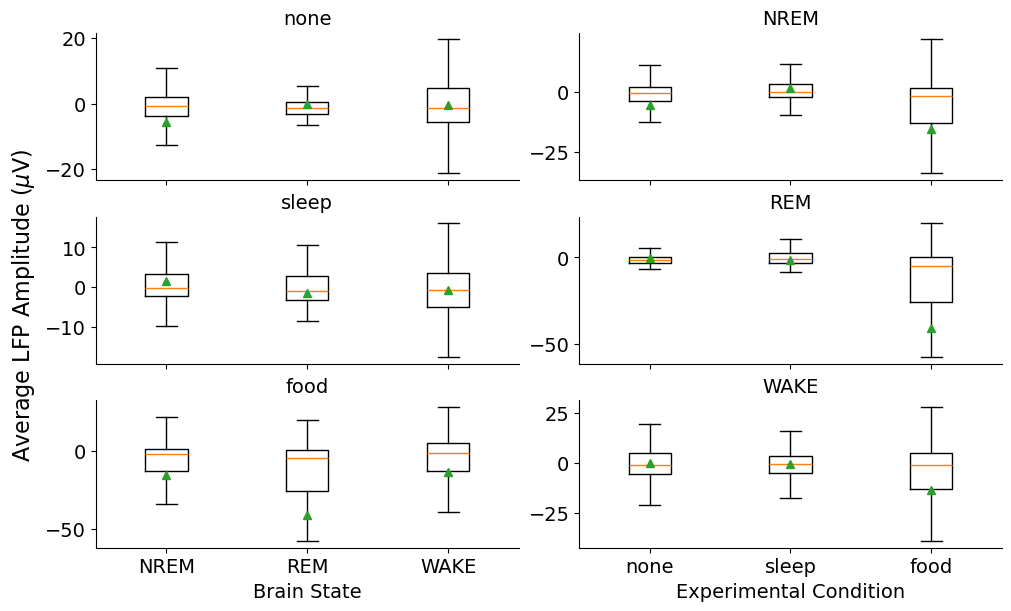

In [ ]:
ch_ind = 6
fig, axs = plt.subplots(
    nrows=3, ncols=2, figsize=(10, 6), sharex="col", constrained_layout=True
)
for exp_cond, ax in zip(full_dict.keys(), axs[:, 0].ravel()):
    nan_mask = {
        state: ~np.isnan(cond_state_traces[exp_cond][state]["hyp"]["avg"][:, ch_ind])
        for state in ["NREM", "REM", "WAKE"]
    }
    tmp_data = [
        cond_state_traces[exp_cond][state]["hyp"]["avg"][:, ch_ind][nan_mask[state]]
        for state in ["NREM", "REM", "WAKE"]
    ]
    ax.boxplot(
        tmp_data,
        showmeans=True,
        showfliers=False,
    )
    ax.set_title(f"{exp_cond}")
    ax.set_xticks(ticks=[1, 2, 3], labels=["NREM", "REM", "WAKE"])
    ax.spines[["top", "right"]].set_visible(False)
axs[-1, 0].set_xlabel("Brain State")
for state, ax in zip(["NREM", "REM", "WAKE"], axs[:, 1].ravel()):

    nan_mask = {
        exp_cond: ~np.isnan(cond_state_traces[exp_cond][state]["hyp"]["avg"][:, ch_ind])
        for exp_cond in full_dict.keys()
    }
    tmp_data = [
        cond_state_traces[exp_cond][state]["hyp"]["avg"][:, ch_ind][nan_mask[exp_cond]]
        for exp_cond in full_dict.keys()
    ]

    ax.boxplot(
        tmp_data,
        showmeans=True,
        showfliers=False,
    )
    ax.set_title(f"{state}")
    ax.set_xticks(ticks=[1, 2, 3], labels=full_dict.keys())
    ax.spines[["top", "right"]].set_visible(False)
axs[-1, 1].set_xlabel("Experimental Condition")
fig.supylabel("Average LFP Amplitude ($\\mu$V)", fontsize=16)

In [54]:
edges = np.histogram_bin_edges(
    cond_state_traces["none"]["NREM"]["hyp"][nan_mask], bins="fd"
)

In [56]:
plt.hist(cond_state_traces["none"]["NREM"]["hyp"][nan_mask], bins=edges)

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f6c04122480> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7e5fc374d8a0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 